# **Objective**
* The goal of this assignment is to design, implement, and evaluate a Convolutional Neural Network (CNN) model using a real-world dataset.

# Part A: Data Understanding and Preprocessing

## 1. Load Data

In [1]:
import json

kaggle_config = {
    "username": "nikhilgopi",
    "key": "KGAT_4f175eb40d99b5c1ce128c4035e92b0f"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                            BMW Global Automotive Sales                              55017  2026-02-22 18:18:38.170000           7859        153  1.0              
shree0910/ai-and-data-science-job-market-dataset-20202026           AI & Data Science Job Market Dataset (2020–2026)        188367  2026-03-09 07:40:43.393000           1522         42  1.0              
ssssws/chocolate-sales-dataset-2023-2024                            Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000           1991         44

In [5]:
!kaggle datasets download -d puneet6060/intel-image-classification --force

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 317MB/s]
100% 346M/346M [00:01<00:00, 311MB/s]


In [6]:
!unzip -o intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [7]:
import os
print(os.listdir())

['.config', 'seg_train', 'seg_pred', 'seg_test', 'intel-image-classification.zip', 'sample_data']


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

## 2. Data Preprocessing

In [9]:
# Training Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
    )

# Test/Validation Data Generator
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'seg_train/seg_train',
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = test_datagen.flow_from_directory(
    'seg_test/seg_test',
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [10]:
# Architecture Implementation
model = Sequential([
    # Layer 1: Conv + ReLU + Pooling
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # Layer 2: Conv + ReLU + Pooling
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Layer 3: Conv + ReLU + Pooling
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Classification Head
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Regularization requirement
    Dense(6, activation='softmax') # Softmax requirement
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Compiling the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Setting up callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_cnn_model.h5', save_best_only=True)
]

# Training the model
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4282 - loss: 1.4041

439/439 ━━━━━━━━━━━━━━━━━━━━ 792s 2s/step - accuracy: 0.5125 - loss: 1.2267 - val_accuracy: 0.6650 - val_loss: 0.8900
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6048 - loss: 1.0270

439/439 ━━━━━━━━━━━━━━━━━━━━ 780s 2s/step - accuracy: 0.6169 - loss: 1.0060 - val_accuracy: 0.7170 - val_loss: 0.7638
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6569 - loss: 0.9113

439/439 ━━━━━━━━━━━━━━━━━━━━ 788s 2s/step - accuracy: 0.6670 - loss: 0.8872 - val_accuracy: 0.7903 - val_loss: 0.6393
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6986 - loss: 0.8363

439/439 ━━━━━━━━━━━━━━━━━━━━ 786s 2s/step - accuracy: 0.7038 - loss: 0.8108 - val_accuracy: 0.8043 - val_loss: 0.5631
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7211 - loss: 0.7579

439/439 ━━━━━━━━━━━━━━━━━━━━ 776s 2s/step - accuracy: 0.7212 - loss: 0.7657 - val_accuracy: 0.8087 - val_loss: 0.5475


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Generate predictions
val_generator.reset()
predictions = model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Report performance metrics
print(classification_report(y_true, y_pred, target_names=class_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 448ms/step
              precision    recall  f1-score   support

   buildings       0.85      0.73      0.79       437
      forest       0.86      0.99      0.92       474
     glacier       0.81      0.76      0.78       553
    mountain       0.73      0.78      0.75       525
         sea       0.80      0.78      0.79       510
      street       0.82      0.82      0.82       501

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000



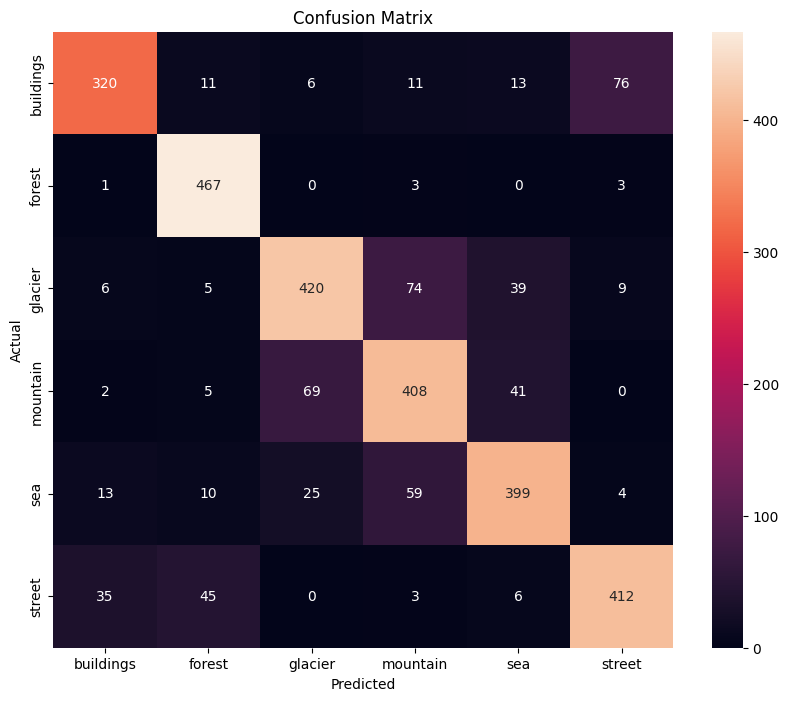

In [13]:
# Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


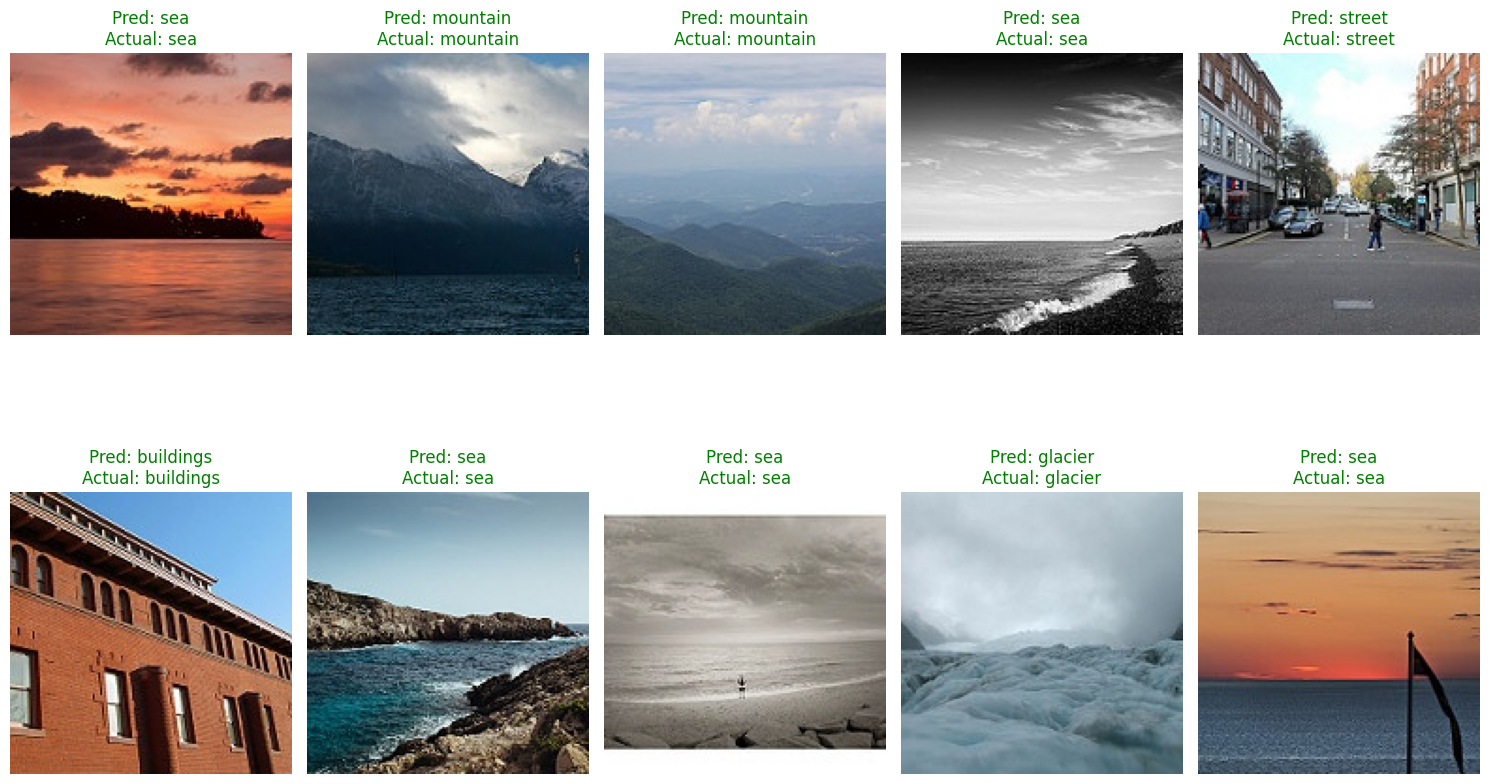

In [15]:
# Visualize 10 random predictions
plt.figure(figsize=(15, 10))
for i in range(10):
    # Select a random index
    idx = np.random.randint(0, len(val_generator.filenames))

    # Load and preprocess image for display
    img_path = os.path.join('seg_test/seg_test', val_generator.filenames[idx])
    img = image.load_img(img_path, target_size=(150, 150))

    # Get model prediction
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred_prob = model.predict(img_array)
    pred_label = class_labels[np.argmax(pred_prob)]
    actual_label = class_labels[y_true[idx]]

    # Plotting
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    color = 'green' if pred_label == actual_label else 'red'
    plt.title(f"Pred: {pred_label}\nActual: {actual_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()